# Calculate the Range of M2 Rigid Body Movement with Mirror

This notebook is to approximate the possible range of M2 rigid body movement with mirror, especially for the x/y direction on the zenith.

## Summary

1. The simulation and measurement of rigid body movement match well for the x-movement of 500 um in zenith.
2. The main constraints of x/y displacement would be the limit switch positions of tangent links in the simulation level.
The available moving range is around +/- 1 mm that is limited by the limit switches, which is verified in the [LVV-E2601](https://jira.lsstcorp.org/secure/Tests.jspa#/testPlayer/testExecution/LVV-E2601).

## Import Modules

This notebook needs to setup the **ts_config_mttcs**, **ts_m2com**, and **ts_aos_utils** under the **notebooks/.user_setups**, which depends on the **ts_tcpip** and **ts_xml**.

In [1]:
%matplotlib inline
%matplotlib widget
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
from astropy.time import Time
from pandas.core.frame import DataFrame

from lsst.ts.m2com import (
    get_config_dir,
    read_yaml_file,
    MockModel,
    TANGENT_LINK_NON_LOAD_BEARING_LINK,
    TANGENT_LINK_LOAD_BEARING_LINK,
)
from lsst.ts.aos.utils import DiagnosticsM2, EfdName

## Declaration of User-Defined Functions

In [2]:
async def get_efd_data(
    diagnostics_m2: DiagnosticsM2,
    time_start: Time,
    time_end: Time,
) -> tuple[DataFrame, DataFrame, dict]:
    """Get the EFD data.

    Parameters
    ----------
    diagnostics_m2 : `lsst.ts.aos.utils.DiagnosticsM2`
        M2 diagnostics instance.
    time_start : `astropy.time.core.Time`
        Start time.
    time_end : `astropy.time.core.Time`
        End time.

    Returns
    -------
    data_zenith_angle : `pandas.core.frame.DataFrame`
        Data of the zenith angle.
    data_position : `pandas.core.frame.DataFrame`
        Data of the position.
    data_force_error_tangent : `dict`
        Data of the tangent force error.
    """

    data_zenith_angle, _ = await diagnostics_m2.get_data_zenith_angle(
        time_start,
        time_end,
    )

    data_position, _ = await diagnostics_m2.get_data_position(
        "position",
        time_start,
        time_end,
    )

    data_force_error_tangent = await diagnostics_m2.get_data_force_error_tangent(
        time_start,
        time_end,
    )

    return data_zenith_angle, data_position, data_force_error_tangent

In [3]:
def get_model(inclinometer_angle: float) -> MockModel:
    """Get the model model.

    Parameters
    ----------
    inclinometer_angle : `float`
        Inclinometer angle in degree.

    Returns
    -------
    model : `MockModel`
        Mock model.
    """

    # Get the model instance
    model = MockModel(inclinometer_angle=inclinometer_angle)
    model.configure(get_config_dir(), "harrisLUT")

    # Configure the mirror stiffness matrix
    model.control_closed_loop.load_file_stiffness(
        get_config_dir() / "harrisLUT" / "stiff_matrix_m2.yaml"
    )
    model.control_closed_loop.set_kinetic_decoupling_matrix()

    # Balance the forces and steps to calculate the hardpoint correction
    for _ in range(10):
        model.balance_forces_and_steps()

    # Do the convergence
    model.control_closed_loop.is_running = True
    for _ in range(60):
        model.balance_forces_and_steps()

    # Calculate the tangent force error
    model._force_error_tangent = model._calculate_force_error_tangent(
        model.control_closed_loop.tangent_forces["measured"]
    )

    return model

In [4]:
def move_x(
    inclinometer_angle: float,
    displacement_x_in_um: float,
    steps_rigid_body: int,
) -> tuple[list[float], np.ndarray[float], np.ndarray[float]]:
    """Move the rigid body in the x-direction.

    Parameters
    ----------
    inclinometer_angle : `float`
        Inclinometer angle in degree.
    displacement_x_in_um : `float`
        Displacement x in um.
    steps_rigid_body : `int`
        Steps of the rigid body movement in each cycle.

    Returns
    -------
    position_x : `list`
        Position x in um.
    `numpy.ndarray`
        Hardpoint displacement in um.
    `numpy.ndarray`
        Tangent force error in N.
    """

    model = get_model(inclinometer_angle);

    # Calculate the steps for the x-displacement
    displacments_xyz = model.control_closed_loop.rigid_body_to_actuator_displacement(
        model.control_closed_loop.get_actuator_location_axial(),
        model.control_closed_loop.get_actuator_location_tangent(),
        model.control_closed_loop.get_radius(),
        displacement_x_in_um * 1e-6,
        0,
        0,
        0,
        0,
        0,
    )
    hardpoints_displacement = (
            displacments_xyz[model.control_closed_loop.hardpoints]
            + np.array(model.control_closed_loop.disp_hardpoint_home)
            - model.get_current_hardpoint_displacement()
    )
    
    # Change the unit to be step
    # The parameters here come frome the actuator xml data in the ts_mtm2_cell
    step_to_mm = np.array([
        1.99714908980000E-5,  # B6
        1.99669217280000E-5,  # B16
        1.99733831430000E-5,  # B26
        6.09090000000000E-6,  # A2
        6.15590000000000E-6,  # A4
        6.12090000000000E-6,  # A6
    ])
    hardpoints_steps = hardpoints_displacement * 1e3 / step_to_mm
    
    model.steps_hardpoints_offset = hardpoints_steps.astype(int)

    # Do the movement
    position_x = list()
    hardpoint_displacement = list()
    force_error_tangent = list()
    while not np.all(model.steps_hardpoints_offset == 0):
        # Calculate the current x-position in m
        hardpoint_displacement_current = model.plant.actuator_steps[
            model.control_closed_loop.hardpoints] * step_to_mm * 1e-3

        x = model.control_closed_loop.hardpoint_to_rigid_body(
            model.control_closed_loop.get_actuator_location_axial(),
            model.control_closed_loop.get_actuator_location_tangent(),
            model.control_closed_loop.get_radius(),
            model.control_closed_loop.hardpoints,
            hardpoint_displacement_current.tolist(),
            model.control_closed_loop.disp_hardpoint_home,
        )[0] * 1e6
    
        position_x.append(x)

        hardpoint_displacement_current_in_um = hardpoint_displacement_current * 1e6
        hardpoint_displacement.append(hardpoint_displacement_current_in_um.tolist())
    
        # Calculate the current tangent force error
        model._force_error_tangent = model._calculate_force_error_tangent(
            model.control_closed_loop.tangent_forces["measured"]
        )

        force_error_tangent_current = (
            model._force_error_tangent["force"]
            + [model._force_error_tangent["weight"]]
            + [model._force_error_tangent["sum"]]
        )
        force_error_tangent.append(force_error_tangent_current)

        # Move steps
        model.balance_forces_and_steps(steps_rigid_body=steps_rigid_body)

    return position_x, np.array(hardpoint_displacement), np.array(force_error_tangent)

In [5]:
def plot_force_error_tangent(
    position_x: list[float],
    force_error_tangent: np.ndarray[float],
    data_position: DataFrame | None = None,
    data_force_error_tangent: DataFrame | None = None,
    show_threshold: bool = False,
) -> None:
    """Plot the tangent force error.

    Parameters
    ----------
    position_x : `list` [`float`]
        Simulated x position in um.
    force_error_tangent : `numpy.ndarray` [`float`]
        Simulated tangent force error in N.
    data_position : `DataFrame` or None, optional
        Position data in EFD. (the default is None)
    data_force_error_tangent: `DataFrame` or None, optional
        Tangent force error data in EFD. (the default is None)
    show_threshold : `bool`, optional
        Show the threshold or not. (the default is False)
    """

    subtitles = [
        "Force Error (A1)",
        "Force Error (A2)",
        "Force Error (A3)",
        "Force Error (A4)",
        "Force Error (A5)",
        "Force Error (A6)",
        "Mirror Weight",
        "Force Sum",
    ]
    thresholds = [
        TANGENT_LINK_NON_LOAD_BEARING_LINK,
        TANGENT_LINK_LOAD_BEARING_LINK,
        TANGENT_LINK_LOAD_BEARING_LINK,
        TANGENT_LINK_NON_LOAD_BEARING_LINK,
        TANGENT_LINK_LOAD_BEARING_LINK,
        TANGENT_LINK_LOAD_BEARING_LINK,
    ]
    
    fig, ax = plt.subplots(4, 2)
    for idx in range(8):
        row = idx // 2
        col = idx % 2
        ax[row, col].plot(
            position_x,
            force_error_tangent[:, idx],
            "b",
        )
    
        if show_threshold and (idx < 6):
            ax[row, col].axhline(y=thresholds[idx], color="black", linestyle = "--") 
            ax[row, col].axhline(y=-thresholds[idx], color="black", linestyle = "--") 
    
        ax[row, col].set_title(subtitles[idx])

    has_data = (data_position is not None) and (data_force_error_tangent or not None)
    if has_data:
        ax[0, 0].plot(data_position.x, data_force_error_tangent["force"][:, 0], "r--")
        ax[0, 1].plot(data_position.x, data_force_error_tangent["force"][:, 1], "r--")
        ax[1, 0].plot(data_position.x, data_force_error_tangent["force"][:, 2], "r--")
        ax[1, 1].plot(data_position.x, data_force_error_tangent["force"][:, 3], "r--")
        ax[2, 0].plot(data_position.x, data_force_error_tangent["force"][:, 4], "r--")
        ax[2, 1].plot(data_position.x, data_force_error_tangent["force"][:, 5], "r--")
        ax[3, 0].plot(data_position.x, data_force_error_tangent["weight"], "r--")
        ax[3, 1].plot(data_position.x, data_force_error_tangent["sum"], "r--")
     
    ax[-1, 0].set_xlabel("Position X (um)")
    ax[-1, 1].set_xlabel("Position X (um)")
    for idx in range(4):
        ax[idx, 0].set_ylabel("Force error (N)")
    
    fig.tight_layout()

    if has_data:
        fig.legend(["Simulation", "Experiment"], loc="lower right")

    plt.show()    

In [6]:
def plot_tangent_hardpoint_displacement(
    position_x: list[float],
    hardpoint_displacement: np.ndarray[float],
) -> None:
    """Plot the displacement of the tangent hardpoints.

    Parameters
    ----------
    position_x : `list` [`float`]
        Position x in um.
    hardpoint_displacement : `numpy.ndarray` [`float`]
        Hardpoint displacement in um.
    """

    plt.figure()
    plt.plot(position_x, hardpoint_displacement[:, 3], "b")
    plt.plot(position_x, hardpoint_displacement[:, 4], "black")
    plt.plot(position_x, hardpoint_displacement[:, 5], "r--")

    plt.xlabel("Position X (um)")
    plt.ylabel("Tangent hardpoint displacement (um)")
    plt.legend(["A2", "A4", "A6"])
    plt.show()

## Compare the Stiffness Value in Matrix and Spec

The axial stiffness has the good match between the stiffness matrix and the spec.
The tangent stiffness in the matrix is around the half of the spec.

In [7]:
stiffness = read_yaml_file(get_config_dir() / "harrisLUT" / "stiff_matrix_m2.yaml")["stiff"]

stiff_axial = abs(int(stiffness[0][0] / 1.99676894470000E-5))  # Value from ts_mtm2_cell
print(f"Axial spec is 2600 N/mm and the matrix element is {stiff_axial} N/mm")

stiff_tangent = abs(int(stiffness[-1][-1] / 6.12090000000000E-6))  # Value from ts_mtm2_cell
print(f"Tangent spec is 30000 N/mm and the matrix element is {stiff_tangent} N/mm")

Axial spec is 2600 N/mm and the matrix element is 2861 N/mm
Tangent spec is 30000 N/mm and the matrix element is 13715 N/mm


## Instantiate the DiagnosticsM2 Class and Query the Data

Notice that the UTC time is used when doing the query.

In [8]:
time_start = Time("2024-07-22T15:38:00", scale="utc", format="isot")
time_end = Time("2024-07-22T15:48:00", scale="utc", format="isot")

In [9]:
diagnostics_m2 = DiagnosticsM2(efd_name=EfdName.Usdf)

In [10]:
data_zenith_angle, data_position, data_force_error_tangent = await get_efd_data(
    diagnostics_m2,
    time_start,
    time_end,
)

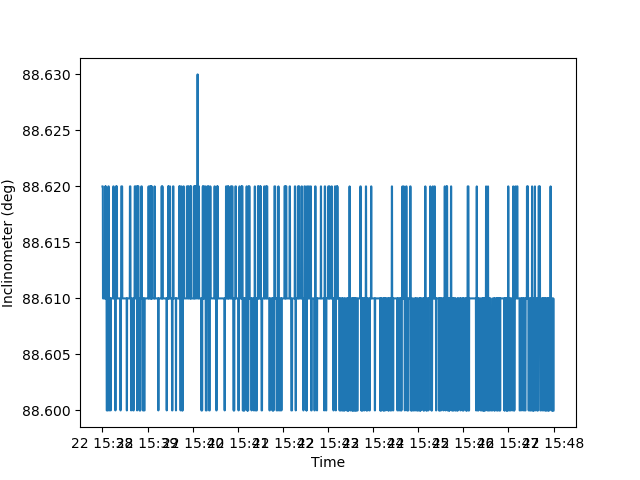

In [11]:
# Check the inclinometer angle
plt.figure()
plt.plot(data_zenith_angle.inclinometerProcessed)
plt.xlabel("Time")
plt.ylabel("Inclinometer (deg)")
plt.show()

## Simulate the X Movement

Since the mirror is symmetric in the simulation, the simulations of x and y directions should be the same.
Therefore, we only simulate the x movement here.

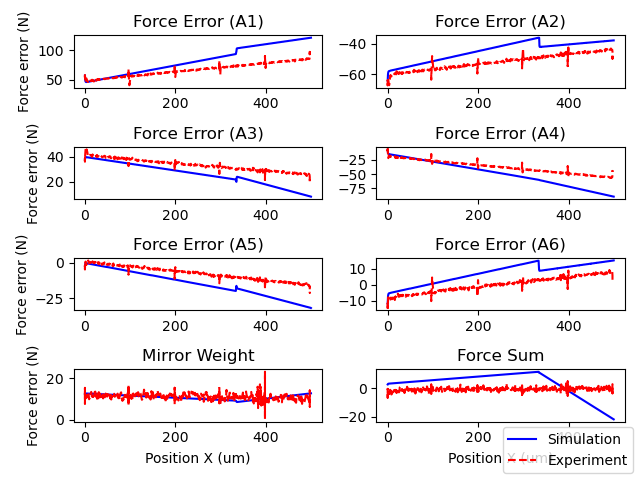

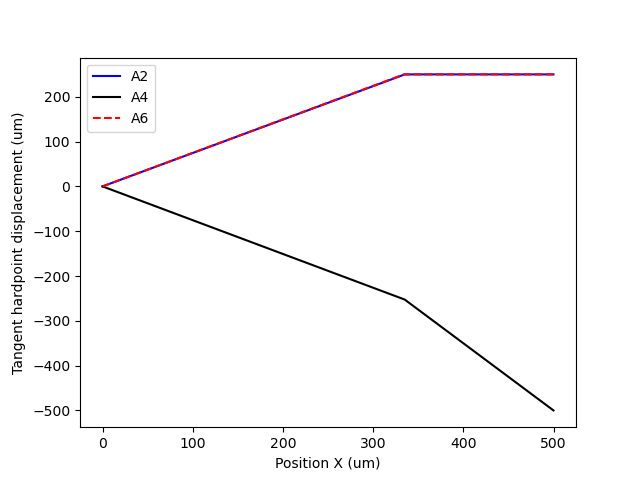

In [12]:
# Zenith
inclinometer_angle = 88.61  # To fit with the experiment data

# Simulate 500 um movement in x direction
displacement_x_in_um = 500

steps_rigid_body = 30
position_x, hardpoint_displacement, force_error_tangent = move_x(
    inclinometer_angle,
    displacement_x_in_um,
    steps_rigid_body,
)

# Check the fitting between the simulation and experiment
plot_force_error_tangent(
    position_x,
    force_error_tangent,
    data_position=data_position,
    data_force_error_tangent=data_force_error_tangent,
    show_threshold=False,
)

# Plot the displacement of tangent links
plot_tangent_hardpoint_displacement(position_x, hardpoint_displacement)

## Simulate the Limitation

The available physical space to move M2 laterally (X and Y) within the cell, is +/- 7.55mm.
Simulate the x movement to be 7000 um to check the constraint of the tangent force error.
There is no issue from it and the only limitation is the limit switch positions of tangent links in the simulation level as verified in the surrogate test (the available movement is around 1mm): [LVV-E2601](https://jira.lsstcorp.org/secure/Tests.jspa#/testPlayer/testExecution/LVV-E2601).

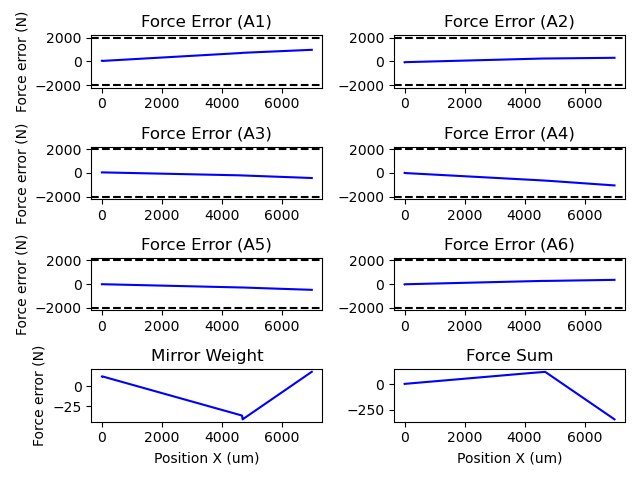

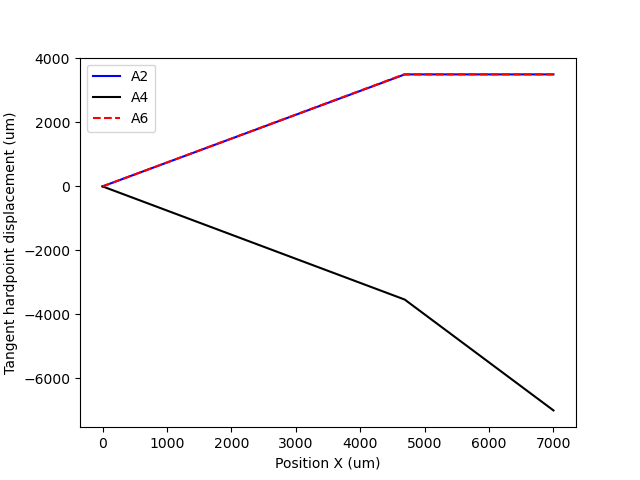

In [13]:
displacement_x_in_um = 7000
position_x, hardpoint_displacement, force_error_tangent = move_x(
    inclinometer_angle,
    displacement_x_in_um,
    steps_rigid_body,
)

plot_force_error_tangent(
    position_x,
    force_error_tangent,
    show_threshold=True,
)

plot_tangent_hardpoint_displacement(position_x, hardpoint_displacement)

In [ ]:
plt.close("all")